<h1 style="color:blue;">Task 3: Sentiment Analysis</h1>

<h2 style="color:green;">Introduction</h2>

Sentiment Analysis is the process of identifying opinions and emotions from text data. In this project, product reviews were analyzed and visualized to understand customer sentiments, ratings, and product performance.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv("Dataset-SA.csv")
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB


In [5]:
df.isnull().sum()

product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64

In [6]:
df = df.dropna()

In [7]:
df['Review'] = df['Review'].fillna('').astype(str).str.lower()

In [8]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [9]:
df['score'] = df['Review'].apply(lambda x: sia.polarity_scores(x)['compound'])

In [10]:
df['predicted_sentiment'] = df['score'].apply(
    lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'neutral')
)

In [11]:
df[['Review', 'Sentiment', 'predicted_sentiment']].head()

,Review,Sentiment,predicted_sentiment
0,super!,positive,positive
1,awesome,positive,positive
2,fair,positive,positive
3,useless product,negative,negative
4,fair,neutral,positive


In [12]:
(df['Sentiment'] == df['predicted_sentiment']).mean()

np.float64(0.7638915838318208)

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['Review'])
y = df['Sentiment']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9148187160439073


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

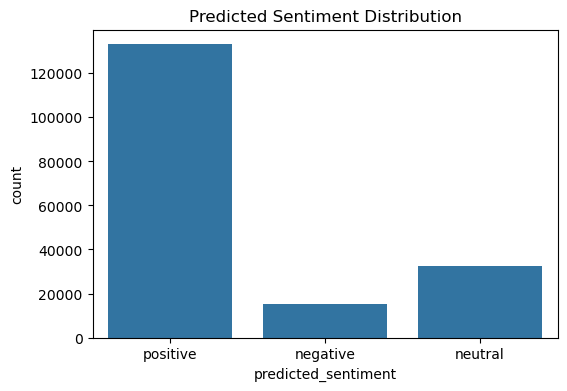

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='predicted_sentiment')
plt.title("Predicted Sentiment Distribution")
plt.show()

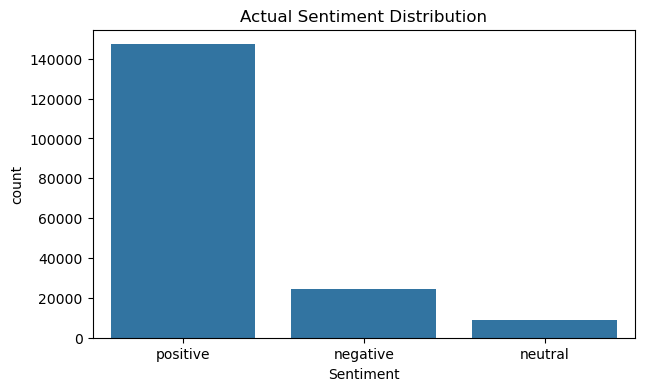

In [19]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Sentiment')
plt.title("Actual Sentiment Distribution")
plt.show()

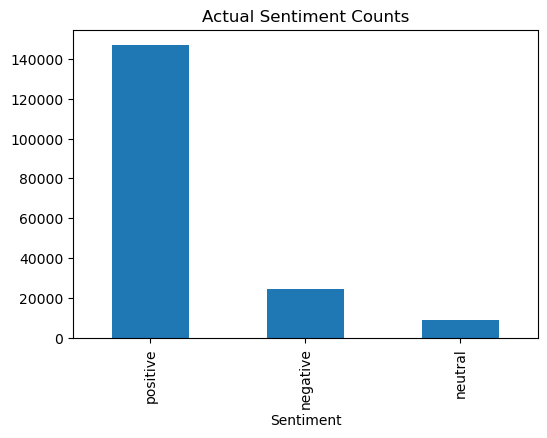

In [20]:
comparison_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(6,4))
comparison_counts.plot(kind='bar')
plt.title("Actual Sentiment Counts")
plt.show()

C:\Users\acer\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


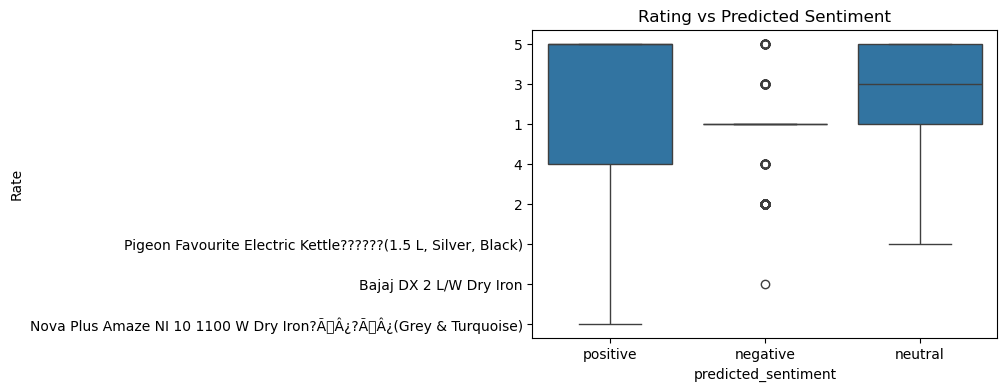

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='predicted_sentiment', y='Rate')
plt.title("Rating vs Predicted Sentiment")
plt.show()

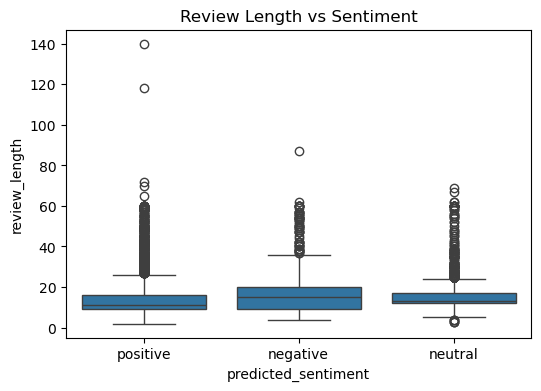

In [24]:
df['review_length'] = df['Review'].apply(len)

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='predicted_sentiment', y='review_length')
plt.title("Review Length vs Sentiment")
plt.show()